# Implementing Logistic Regression From First Principles
Data sourced from https://www.kaggle.com/code/fareselmenshawii/logistic-regression?select=breast-cancer.csv

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Analysing Data

In [161]:
raw = pd.read_csv("breast-cancer.csv")
raw.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [162]:
# More columns than rows
raw.head(10).T

,0,1,2,3,4,5,6,7,8,9
id,842302,842517,84300903,84348301,84358402,843786,844359,84458202,844981,84501001
diagnosis,M,M,M,M,M,M,M,M,M,M
radius_mean,17.99,20.57,19.69,11.42,20.29,12.45,18.25,13.71,13.0,12.46
texture_mean,10.38,17.77,21.25,20.38,14.34,15.7,19.98,20.83,21.82,24.04
perimeter_mean,122.8,132.9,130.0,77.58,135.1,82.57,119.6,90.2,87.5,83.97
area_mean,1001.0,1326.0,1203.0,386.1,1297.0,477.1,1040.0,577.9,519.8,475.9
smoothness_mean,0.1184,0.08474,0.1096,0.1425,0.1003,0.1278,0.09463,0.1189,0.1273,0.1186
compactness_mean,0.2776,0.07864,0.1599,0.2839,0.1328,0.17,0.109,0.1645,0.1932,0.2396
concavity_mean,0.3001,0.0869,0.1974,0.2414,0.198,0.1578,0.1127,0.09366,0.1859,0.2273
concave points_mean,0.1471,0.07017,0.1279,0.1052,0.1043,0.08089,0.074,0.05985,0.09353,0.08543


In [163]:
raw.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [164]:
raw.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [165]:
raw.columns.tolist()

['id',
 'diagnosis',
 'radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']

The data does not have any null values, and every non-target variable excluding id is a continuous numerical variable.

## Feature Engineering

In [ ]:
raw.drop(['id'], axis=1, inplace=True)

# Encoding for target variable
raw['diagnosis'] = raw['diagnosis'].map({'M': 1, 'B': 0})

### Find Relevant Features

In [167]:
# Use correlation coefficients for feature selection.
raw.corr()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


In [168]:
# Find strength of correlation between features and target variable
cor = abs(raw.corr()['diagnosis'])

# Select features with correlation greater than 0.1
features_cor = cor[cor > 0.1]

# Get names of selected features
features = features_cor.index.tolist()

features.remove('diagnosis')
features

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'radius_se',
 'perimeter_se',
 'area_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']

### Split Data

In [169]:
# Split data into training and testing sets
X = raw[features]
y = raw['diagnosis']
X_train = X[:int(0.8*len(X))]
y_train = y[:int(0.8*len(y))]
X_test = X[int(0.8*len(X)):]
y_test = y[int(0.8*len(y)):]

### Feature Scaling

In [170]:
# Normalise the data
def normalise(X):
    return (X - np.mean(X, axis=0)) / np.std(X, axis=0)

X_train_scaled = normalise(X_train)

# No need to normalise target variable as it is binary.

## Model Training

### Cost Function and Gradients

In [171]:
# Define the necessary functions
def f(X, w, b):
    return X @ w + b

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def J(X, y, w, b):
    m = len(X)
    z = f(X, w, b)
    h = sigmoid(z)
    return -1/m * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))

def dJ_dw(X, y, w, b):
    m = len(X)
    z = f(X, w, b)
    h = sigmoid(z)
    return 1/m * X.T @ (h - y)

def dJ_db(X, y, w, b):
    m = len(X)
    z = f(X, w, b)
    h = sigmoid(z)
    return 1/m * np.sum(h - y)

### Gradient Descent

In [172]:
# Define hyperparameters
alpha = 1e-2
num_iterations = 10 ** 3

# Gradient descent algorithm
w_scaled = np.zeros(X_train_scaled.shape[1])
b_scaled = 0
for _  in range(num_iterations):
    temp_w = w_scaled - alpha * dJ_dw(X_train_scaled, y_train, w_scaled, b_scaled)
    temp_b = b_scaled - alpha * dJ_db(X_train_scaled, y_train, w_scaled, b_scaled)
    w_scaled = temp_w
    b_scaled = temp_b

# Unscale coefficients
w = w_scaled / np.std(X_train, axis=0)
b = b_scaled - np.sum(w_scaled * np.mean(X_train, axis=0) / np.std(X_train, axis=0))
w, b

(radius_mean                 0.113268
 texture_mean                0.101988
 perimeter_mean              0.016154
 area_mean                   0.001086
 smoothness_mean            11.674918
 compactness_mean            2.192864
 concavity_mean              2.839577
 concave points_mean         9.110074
 symmetry_mean               1.091711
 radius_se                   1.098955
 perimeter_se                0.132207
 area_se                     0.006933
 compactness_se             -8.350184
 concavity_se               -4.623935
 concave points_se           5.727019
 radius_worst                0.095107
 texture_worst               0.075303
 perimeter_worst             0.013260
 area_worst                  0.000743
 smoothness_worst           15.026048
 compactness_worst           1.286158
 concavity_worst             1.284448
 concave points_worst        6.329839
 symmetry_worst              3.529989
 fractal_dimension_worst     4.424557
 dtype: float64,
 np.float64(-19.431544488851515))

## Model Evaluation

### Comparing Costs

In [173]:
J(X_train, y_train, np.zeros(X_train.shape[1]), 0), J(X_train, y_train, w, b)

(np.float64(0.6931471805599453), np.float64(0.10189231844999279))

In [174]:
J(X_test, y_test, np.zeros(X_test.shape[1]), 0), J(X_test, y_test, w, b)

(np.float64(0.6931471805599453), np.float64(0.12565374936271867))

### Visualisation

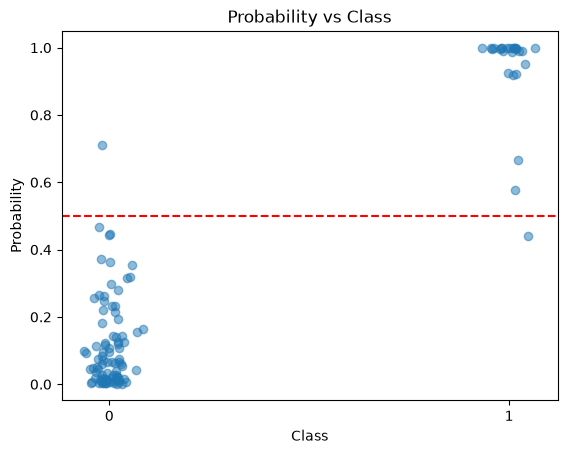

In [186]:
y_prob = sigmoid(f(X_test, w, b))

# Add deviation for visual clarity
jitter = np.random.normal(0, 0.03, size=len(y_test))

plt.scatter(y_test + jitter, y_prob, alpha=0.5)
plt.axhline(0.5, color="red", linestyle="--")
plt.xlabel("Class")
plt.ylabel("Probability")
plt.xticks([0, 1])
plt.title("Probability vs Class")
plt.show()


The model is mostly correct, except for one false negative and one false positive.

### Evaluation Metrics

In [176]:
# Map probabilities to predictions
y_pred = np.where(y_prob >= 0.5, 1, 0)

# Find true positives, true negatives, false positives, and false negatives
TP = ((y_pred == 1) & (y_test == 1)).sum()
TN = ((y_pred == 0) & (y_test == 0)).sum()
FP = ((y_pred == 1) & (y_test == 0)).sum()
FN = ((y_pred == 0) & (y_test == 1)).sum()
TP, TN, FP, FN

(np.int64(25), np.int64(87), np.int64(1), np.int64(1))

In [177]:
# Calculate metrics
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
F1 = 2 * (precision * recall) / (precision + recall)
accuracy, precision, recall, F1

(np.float64(0.9824561403508771),
 np.float64(0.9615384615384616),
 np.float64(0.9615384615384616),
 np.float64(0.9615384615384616))

The model makes correct predictions 98.25% of the time, 96.15% of its positive predictions are correct, 96.15% of the positive cases where correctly predicted by the model, and it achieved an F1 score of 0.9615

## Comparison with Libraries

In [178]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [179]:
# Split data into training and testing sets
X_train_lib, X_test_lib, y_train_lib, y_test_lib = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialise and train model
model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train_lib, y_train_lib)

# Predict values
y_pred_lib = model.predict(X_test_lib)

# Evaluation
f1_score(y_test_lib, y_pred_lib)

0.9523809523809523

The model made from scratch performs similarly to the scikit-learn library.